In [2]:
import cv2
import pywt
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def get_wavelet_hash(img, wavelet='db4', level=3):
    # Chuyển ảnh xám và resize
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    res = cv2.resize(gray, (64, 64))
    # Biến đổi Wavelet
    coeffs = pywt.wavedec2(res, wavelet, level=level)
    ll_coeffs = coeffs[0]
    # Tạo mã băm
    avg = np.mean(ll_coeffs)
    return (ll_coeffs > avg).astype(int).flatten()

def hamming_dist(h1, h2):
    return np.count_nonzero(h1 != h2)

In [3]:
# Đọc 2 ảnh gốc
img_h = cv2.imread('data/husky.jpeg')
img_m = cv2.imread('data/meo.jpeg')

def create_variants(img):
    variants = [img] # Giữ ảnh gốc
    # 1. Xoay nhẹ
    rows, cols, _ = img.shape
    for angle in [5, -5, 10]:
        M = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1)
        variants.append(cv2.warpAffine(img, M, (cols, rows)))
    # 2. Làm mờ
    variants.append(cv2.GaussianBlur(img, (7, 7), 0))
    # 3. Thay đổi độ sáng
    variants.append(cv2.convertScaleAbs(img, alpha=1.1, beta=20))
    variants.append(cv2.convertScaleAbs(img, alpha=0.9, beta=-20))
    return variants

husky_vars = create_variants(img_h)
meo_vars = create_variants(img_m)

# Tính Hash cho tất cả
hash_h = [get_wavelet_hash(v) for v in husky_vars]
hash_m = [get_wavelet_hash(v) for v in meo_vars]

# --- TẠO CÁC CẶP SO SÁNH ---
y_true = []   # 1: Giống, 0: Khác
y_scores = [] # Khoảng cách Hamming

# Cặp Giống (Husky-Husky, Mèo-Mèo)
for i in range(len(hash_h)):
    for j in range(i+1, len(hash_h)):
        y_true.append(1)
        y_scores.append(hamming_dist(hash_h[i], hash_h[j]))
        y_true.append(1)
        y_scores.append(hamming_dist(hash_m[i], hash_m[j]))

# Cặp Khác (Husky-Mèo)
for h in hash_h:
    for m in hash_m:
        y_true.append(0)
        y_scores.append(hamming_dist(h, m))

print(f"Đã tạo {len(y_true)} cặp so sánh từ 2 ảnh gốc!")

Đã tạo 91 cặp so sánh từ 2 ảnh gốc!


Accuracy: 0.84
Sensitivity: 0.64
Specificity: 1.00


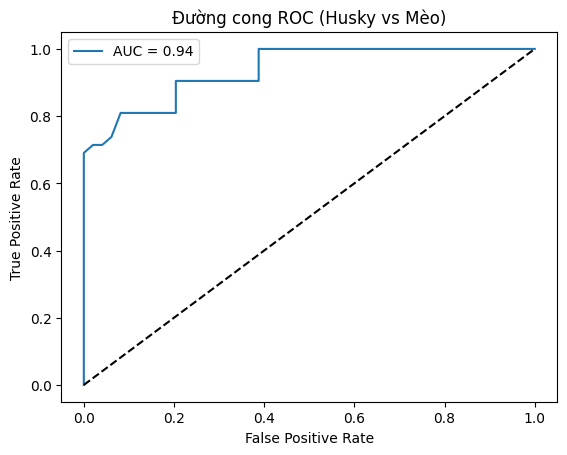

In [4]:
# Tính các chỉ số tại ngưỡng 50
threshold = 50
y_pred = [1 if s <= threshold else 0 for s in y_scores]

tp = sum((y_t == 1 and y_p == 1) for y_t, y_p in zip(y_true, y_pred))
fp = sum((y_t == 0 and y_p == 1) for y_t, y_p in zip(y_true, y_pred))
tn = sum((y_t == 0 and y_p == 0) for y_t, y_p in zip(y_true, y_pred))
fn = sum((y_t == 1 and y_p == 0) for y_t, y_p in zip(y_true, y_pred))

print(f"Accuracy: {(tp+tn)/len(y_true):.2f}")
print(f"Sensitivity: {tp/(tp+fn):.2f}")
print(f"Specificity: {tn/(tn+fp):.2f}")

# Vẽ ROC
fpr, tpr, _ = roc_curve(y_true, [-s for s in y_scores])
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Đường cong ROC (Husky vs Mèo)')
plt.legend()
plt.show()